In [1]:
import io
import re
from datetime import datetime

import numpy as np
import pandas as pd
import requests

# -------------------------
# Configuración / constantes
# -------------------------

SHEET_ID = "1mBKnm0gjecNJcjhzf4rlXfdAi8LAy9Ly"
SHEET_NAME = "Especies"

URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=xlsx"

source_year_map = {
    "Bol_47": 1998,
    "CAZA": 1998,
    "L_Rojo_Flora": 1989,
    "L_Rojo_Vert": 1989,
    "Núñez et al. 1997": 1997,
    "Yáñez et al. 1997": 1997,
}

weight_category_map = {
    "LC": 0,
    "DD": 0,
    "R": 0,
    "NT": 1,
    "VU": 2,
    "EN": 3,
    "CR": 4,
    "EX": 5,
    "EW": 5,
}

w_max = 5  # Peso máximo para el cálculo del RLI


# -------------------------
# Funciones auxiliares
# -------------------------

def get_year_from_source(value):
    """Obtiene un año desde la fuente de categoría:
    1) Usa el mapa source_year_map si calza algún código.
    2) Si no, extrae el primer año (4 dígitos) del texto.
    3) Si nada aplica, devuelve pd.NA.
    """
    if pd.isna(value):
        return pd.NA

    s = str(value)

    # 1) Revisar el mapeo explícito
    for key, year in source_year_map.items():
        if key in s:
            return year

    # 2) Extraer año por regex
    match = re.search(r"(\d{4})", s)
    if match:
        return int(match.group(1))

    # 3) Nada encontrado
    return pd.NA


def extract_code(value):
    """Extrae el mejor código de categoría (LC, NT, VU, EN, etc.)
    a partir de un texto. Si no encuentra nada, devuelve None.
    """
    if pd.isna(value):
        return None

    s = str(value).upper()
    codes = re.findall(r"\b(LC|DD|R|NT|VU|EN|CR|EX|EW)\b", s)
    if not codes:
        return None

    # Elige el código de mayor peso según weight_category_map
    best = max(codes, key=lambda c: weight_category_map.get(c, -1))
    return best


def build_progressive(df: pd.DataFrame, year_col: str) -> pd.DataFrame:
    """Construye la progresión acumulativa de especies año a año,
    a partir de la columna year_col. Rellena todos los años desde
    el primer año observado hasta el año actual.
    """
    df_tmp = df.copy()

    if year_col not in df_tmp.columns:
        raise KeyError(f"La columna '{year_col}' no existe en el DataFrame.")

    # Crear columna auxiliar 'year' para la progresión
    df_tmp["year"] = df_tmp[year_col]

    # Ordenar
    df_tmp = df_tmp.sort_values(["year", "scientific_name"])
    valid_years = df_tmp["year"].dropna().astype(int)

    if valid_years.empty:
        # No hay años válidos
        return df_tmp.iloc[0:0].copy()

    start_year = int(valid_years.min())
    end_year = datetime.now().year
    years = list(range(start_year, end_year + 1))

    results = []

    # Año inicial
    year_initial = years[0]
    df_prev = df_tmp[df_tmp["year"] == year_initial].copy()
    results.append(df_prev)

    # Progresión
    for year in years[1:]:
        df_actual = df_tmp[df_tmp["year"] == year].copy()
        especies_actuales = set(df_actual["scientific_name"])

        # Especies que estaban antes pero no aparecen este año
        faltantes = df_prev[~df_prev["scientific_name"].isin(especies_actuales)].copy()
        faltantes["year"] = year

        # Unir nuevas + arrastradas
        df_year_full = pd.concat([df_actual, faltantes], ignore_index=True)
        results.append(df_year_full)
        df_prev = df_year_full

    df_cumulativo = pd.concat(results, ignore_index=True)
    df_cumulativo = df_cumulativo.sort_values(["year", "scientific_name"])
    return df_cumulativo


def compute_rli(group: pd.DataFrame) -> pd.Series:
    """Calcula el RLI sobre un grupo de filas (año, o global)."""
    N = len(group)
    sum_w = group["weight_category"].sum()
    rli = 1 - (sum_w / (N * w_max)) if N > 0 else np.nan
    return pd.Series(
        {
            "n_especies": N,
            "suma_pesos": sum_w,
            "RLI": rli,
        }
    )


# -------------------------
# Descarga y preparación del DataFrame
# -------------------------

resp = requests.get(URL)
resp.raise_for_status()

df = pd.read_excel(
    io.BytesIO(resp.content),
    sheet_name=SHEET_NAME,
)

# Año actual desde el decreto vigente
df["ref_decreto"] = df["REFERENCIA o DECRETO\nCategoría Vigente"]
df["year_current"] = (
    df["ref_decreto"]
    .astype(str)
    .str.extract(r"(\d{4})", expand=False)
    .astype("Int64")
)

# Renombrar columnas largas a nombres manejables
old_name = [c for c in df.columns if c.startswith("Categoría ANTE ANTERIOR a RCE actual")][0]
df = df.rename(columns={old_name: "preview_category_rce_0"})

old_name = [c for c in df.columns if c.startswith("Fuente Categoría  ANTE ANTERIOR a RCE actual")][0]
df = df.rename(columns={old_name: "source_preview_category_rce_0"})

df["year_source_preview_category_rce_0"] = (
    df["source_preview_category_rce_0"]
    .apply(get_year_from_source)
    .astype("Int64")
)

old_name = [c for c in df.columns if c.startswith("Categoría ANTERIOR a RCE actual")][0]
df = df.rename(columns={old_name: "preview_category_rce_1"})

old_name = [c for c in df.columns if c.startswith("Fuente Categoría ANTERIOR a RCE actual")][0]
df = df.rename(columns={old_name: "source_preview_category_rce_1"})

df["year_source_preview_category_rce_1"] = (
    df["source_preview_category_rce_1"]
    .apply(get_year_from_source)
    .astype("Int64")
)

old_name = [c for c in df.columns if "CATEGORÍA VIGENTE" in c][0]
df = df.rename(columns={old_name: "current_category"})

df = df.rename(
    columns={
        "NOMBRE CIENTÍFICO": "scientific_name",
        "REINO": "kingdom",
    }
)


# -------------------------
# Progresión por etapas (0, 1, vigente)
# -------------------------
# -------------------------
# df_cumulativo_0
# -------------------------
df_cumulativo_0 = build_progressive(df, "year_source_preview_category_rce_0")
# -------------------------
# Codificar categorías y pesos
# -------------------------
df_cumulativo_0["category_code"] = df_cumulativo_0["preview_category_rce_0"].apply(extract_code)
# Excluir DD y R
df_cumulativo_0 = df_cumulativo_0[~df_cumulativo_0["category_code"].isin(["DD", "R"])]
df_cumulativo_0["weight_category"] = df_cumulativo_0["category_code"].map(weight_category_map).astype("Int64")
# Eliminar filas sin categoría o sin peso
df_cumulativo_0 = df_cumulativo_0.dropna(subset=["category_code", "weight_category"])
# -------------------------
# df_cumulativo_1
# -------------------------
df_cumulativo_1 = build_progressive(df, "year_source_preview_category_rce_1")
# -------------------------
# Codificar categorías y pesos
# -------------------------
df_cumulativo_1["category_code"] = df_cumulativo_1["preview_category_rce_1"].apply(extract_code)
# Excluir DD y R
df_cumulativo_1 = df_cumulativo_1[~df_cumulativo_1["category_code"].isin(["DD", "R"])]
df_cumulativo_1["weight_category"] = df_cumulativo_1["category_code"].map(weight_category_map).astype("Int64")
# Eliminar filas sin categoría o sin peso
df_cumulativo_1 = df_cumulativo_1.dropna(subset=["category_code", "weight_category"])
# -------------------------
# df_cumulativo_vigente
# -------------------------
df_cumulativo_vigente = build_progressive(df, "year_current")
# -------------------------
# Codificar categorías y pesos
# -------------------------
df_cumulativo_vigente["category_code"] = df_cumulativo_vigente["current_category"].apply(extract_code)
# Excluir DD y R
df_cumulativo_vigente = df_cumulativo_vigente[~df_cumulativo_vigente["category_code"].isin(["DD", "R"])]
df_cumulativo_vigente["weight_category"] = df_cumulativo_vigente["category_code"].map(weight_category_map).astype("Int64")
# Eliminar filas sin categoría o sin peso
df_cumulativo_vigente = df_cumulativo_vigente.dropna(subset=["category_code", "weight_category"])
# Marcar la etapa (para luego "pisar" los registros)
df_cumulativo_0["stage"] = 0
df_cumulativo_1["stage"] = 1
df_cumulativo_vigente["stage"] = 2

# Unir y hacer que etapas más recientes reemplacen a las antiguas
df_cumulativo = pd.concat(
    [df_cumulativo_0, df_cumulativo_1, df_cumulativo_vigente],
    ignore_index=True,
)

df_cumulativo = df_cumulativo.sort_values(["scientific_name", "year", "stage"])

df_cumulativo = (
    df_cumulativo
    .drop_duplicates(subset=["scientific_name", "year"], keep="last")
    .sort_values(["year", "scientific_name"])
    .reset_index(drop=True)
)

# Si quisieras eliminar un año problemático (ej. 1998):
# df_cumulativo = df_cumulativo[df_cumulativo["year"] != 1998]

# -------------------------
# Cálculo del RLI
# -------------------------

rli_global = compute_rli(df_cumulativo)
print("RLI global:")
print(rli_global)

rli_year = (
    df_cumulativo
    .groupby("year")
    .apply(compute_rli)
    .reset_index()
    .sort_values("year")
)

print("\nRLI por año:")
print(rli_year)


RLI global:
n_especies    23692.000000
suma_pesos    52625.000000
RLI               0.555757
dtype: float64

RLI por año:
    year  n_especies  suma_pesos       RLI
0   1997        28.0        71.0  0.492857
1   1998       348.0       837.0  0.518966
2   1999       348.0       837.0  0.518966
3   2000       348.0       837.0  0.518966
4   2001       348.0       837.0  0.518966
5   2002       348.0       837.0  0.518966
6   2003       348.0       837.0  0.518966
7   2004       348.0       837.0  0.518966
8   2005       348.0       837.0  0.518966
9   2006       348.0       837.0  0.518966
10  2007       361.0       880.0  0.512465
11  2008       432.0      1067.0  0.506019
12  2009       495.0      1265.0  0.488889
13  2010       495.0      1265.0  0.488889
14  2011       718.0      1877.0  0.477159
15  2012       761.0      1898.0  0.501183
16  2013       850.0      1999.0  0.529647
17  2014       900.0      2092.0  0.535111
18  2015       986.0      2254.0  0.542799
19  2016      1047

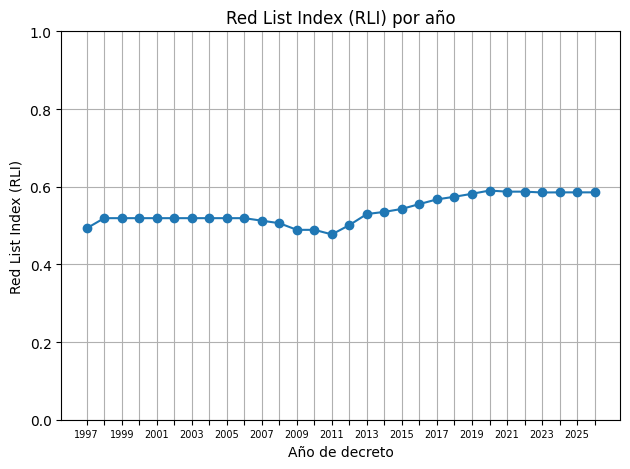

In [7]:

import matplotlib.pyplot as plt
rli_year = rli_year.sort_values("year")
rli_clean = rli_year.copy()
rli_clean = rli_clean.dropna(subset=["year", "RLI"])
rli_clean["year"] = rli_clean["year"].astype(int)
rli_clean["RLI"] = rli_clean["RLI"].astype(float)
fig, ax = plt.subplots()

ax.plot(
    rli_clean["year"],
    rli_clean["RLI"],
    marker="o"
)

ax.set_xlabel("Año de decreto")
ax.set_xticks(rli_clean["year"])
ax.tick_params(axis="x", labelsize=7)
years = rli_clean["year"].values
ticks = years[::2]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks)
ax.set_ylabel("Red List Index (RLI)")
ax.set_title("Red List Index (RLI) por año")
ax.set_ylim(0, 1)
ax.set_xticks(rli_clean["year"])
ax.grid(True)
plt.tight_layout()
plt.show()

In [8]:
rli_year_kingdom = (
    df_cumulativo
    .groupby(["year", "kingdom"])
    .apply(compute_rli)
    .reset_index()
    .sort_values("year")
)

print("\nRLI por reino y año:")
print(rli_year_kingdom)


RLI por reino y año:
    year   kingdom  n_especies  suma_pesos       RLI
0   1997  Animalia        28.0        71.0  0.492857
1   1998  Animalia       171.0       426.0  0.501754
2   1998     Fungi        23.0        48.0  0.582609
3   1998   Plantae       154.0       363.0  0.528571
4   1999  Animalia       171.0       426.0  0.501754
..   ...       ...         ...         ...       ...
82  2025  Animalia       699.0      1377.0  0.606009
84  2025   Plantae       669.0      1595.0  0.523169
86  2026     Fungi       125.0       123.0  0.803200
85  2026  Animalia       699.0      1377.0  0.606009
87  2026   Plantae       669.0      1595.0  0.523169

[88 rows x 5 columns]


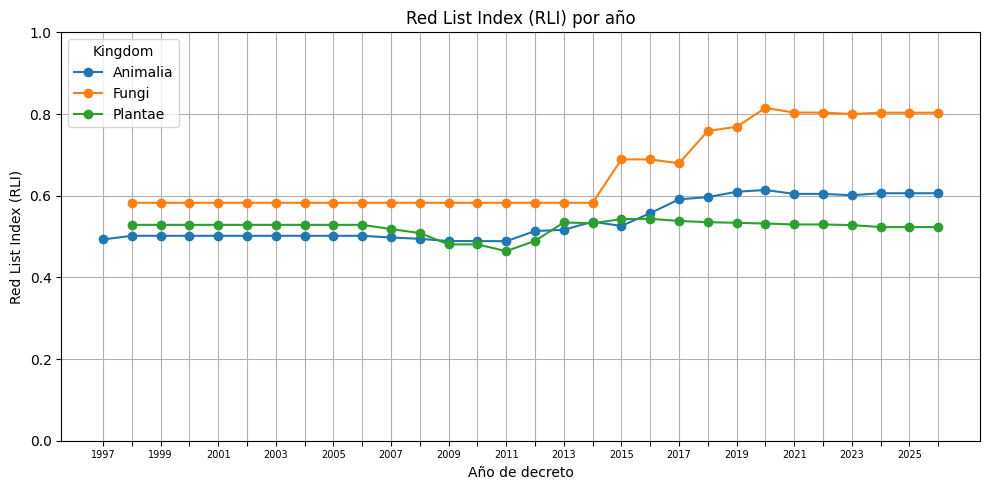

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

for kingdom, group in rli_year_kingdom.groupby("kingdom"):
    ax.plot(
        group["year"],
        group["RLI"],
        marker="o",
        label=kingdom,
    )

ax.legend(title="Kingdom")
ax.set_xlabel("Año de decreto")
ax.set_xticks(rli_clean["year"])
ax.tick_params(axis="x", labelsize=7)
years = rli_clean["year"].values
ticks = years[::2]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks)
ax.set_ylabel("Red List Index (RLI)")
ax.set_title("Red List Index (RLI) por año")
ax.set_ylim(0, 1)
ax.set_xticks(rli_clean["year"])
ax.grid(True)

plt.tight_layout()
plt.show()




In [10]:
import os
from dotenv import load_dotenv

load_dotenv("local.env")  # carga las variables al entorno

DB_USER = os.getenv("SEVENNR_DB_USER")
DB_PASS = os.getenv("SEVENNR_DB_PASSWORD")
DB_NAME = os.getenv("SEVENNR_DB_NAME")
DB_HOST = os.getenv("POSTGRES_HOST")
DB_PORT = os.getenv("POSTGRES_PORT")

from sqlalchemy import create_engine

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)


In [11]:
rli_clean.to_sql(
    "rli",
    engine,
    schema="aggregations",
    if_exists="replace",
    index=False,
)

OperationalError: (psycopg2.OperationalError) connection to server at "db" (172.24.0.2), port 5432 failed: FATAL:  password authentication failed for user "sevennr_user"

(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [ ]:
df_cumulativo.to_excel("rli_base.xlsx", index=False)

In [14]:
DB_PORT

'5432'